In [13]:
"""
Two-Stage MRI Classification Pipeline with Publication-Quality Visualizations
Stage 1: Binary Classifier (Normal vs Tumor) - uses ALL data
Stage 2: Multiclass Classifier (Meningioma vs Glioma vs Pituitary) - uses ONLY known tumor types
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import warnings
warnings.filterwarnings('ignore')


 TWO-STAGE MRI CLASSIFICATION PIPELINE

 Stage 1: Binary Classifier (Normal vs Tumor) - uses ALL data
 Stage 2: Multiclass Classifier (Tumor Types) - uses ONLY known tumor types

 STAGE 1: Preparing Binary Classifier Data

 STAGE 1: Training Binary Classifier (Normal vs Tumor)
Training samples: 14514
Validation samples: 3113
Epoch 1/3
454/454 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.8129 - loss: 0.4894 - val_accuracy: 0.5011 - val_loss: 2.4327 - learning_rate: 0.0010
Epoch 2/3
454/454 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.8896 - loss: 0.2779 - val_accuracy: 0.7671 - val_loss: 0.6244 - learning_rate: 0.0010
Epoch 3/3
454/454 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.9184 - loss: 0.2117 - val_accuracy: 0.9425 - val_loss: 0.1784 - learning_rate: 0.0010


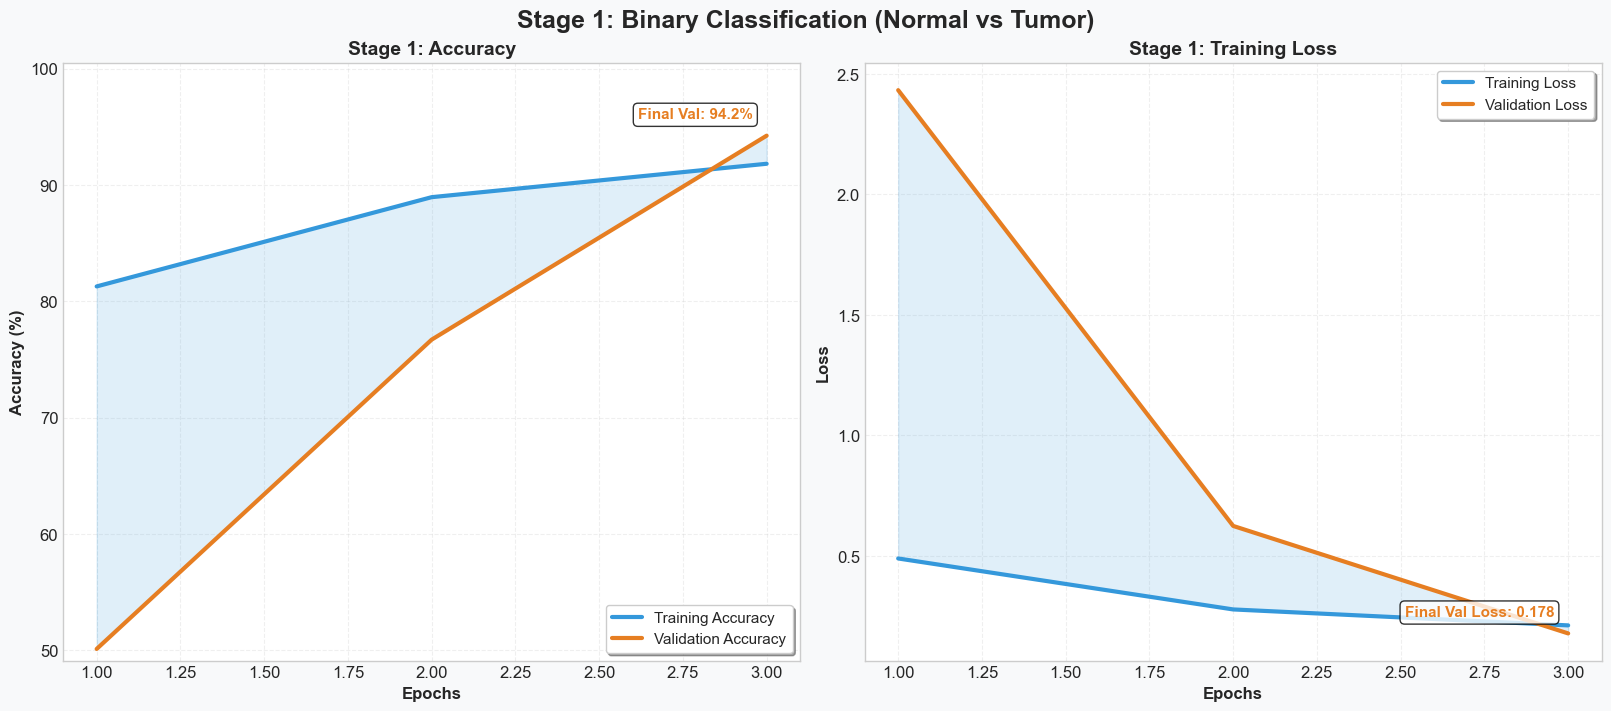


   Evaluating Stage 1 Classifier


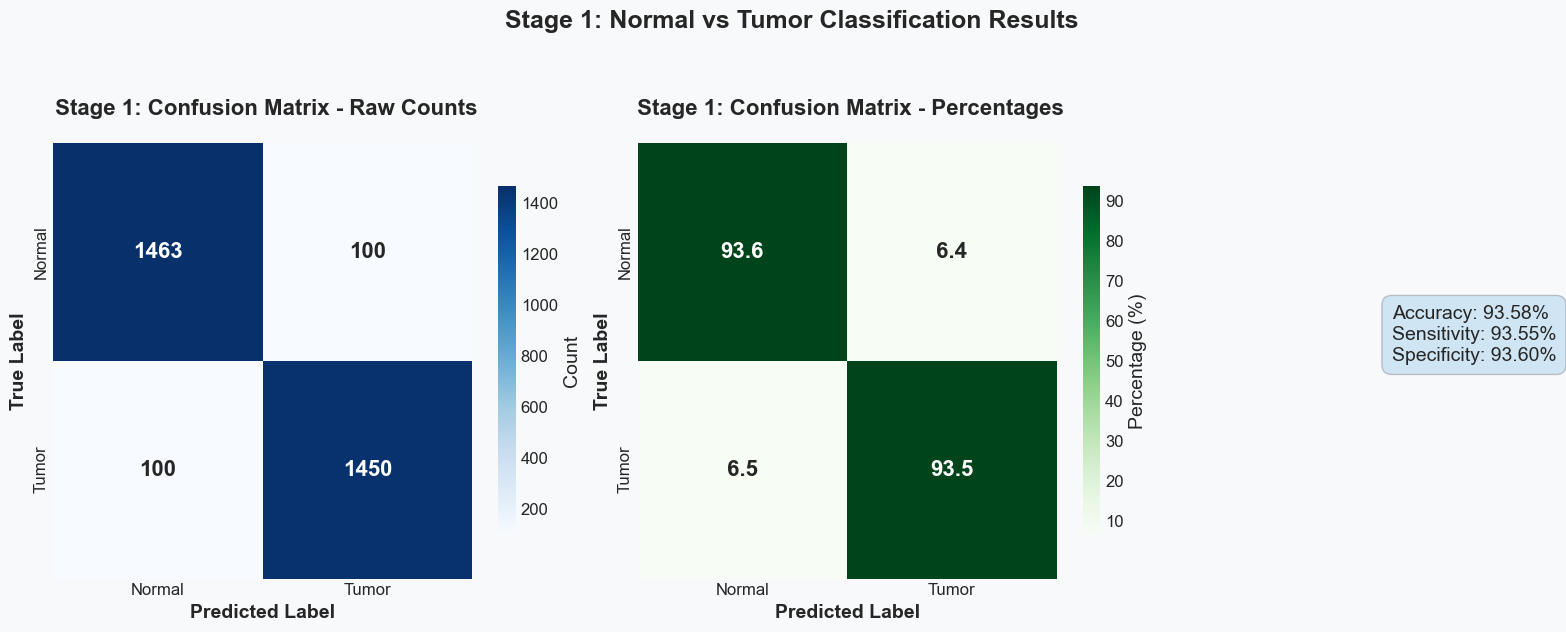

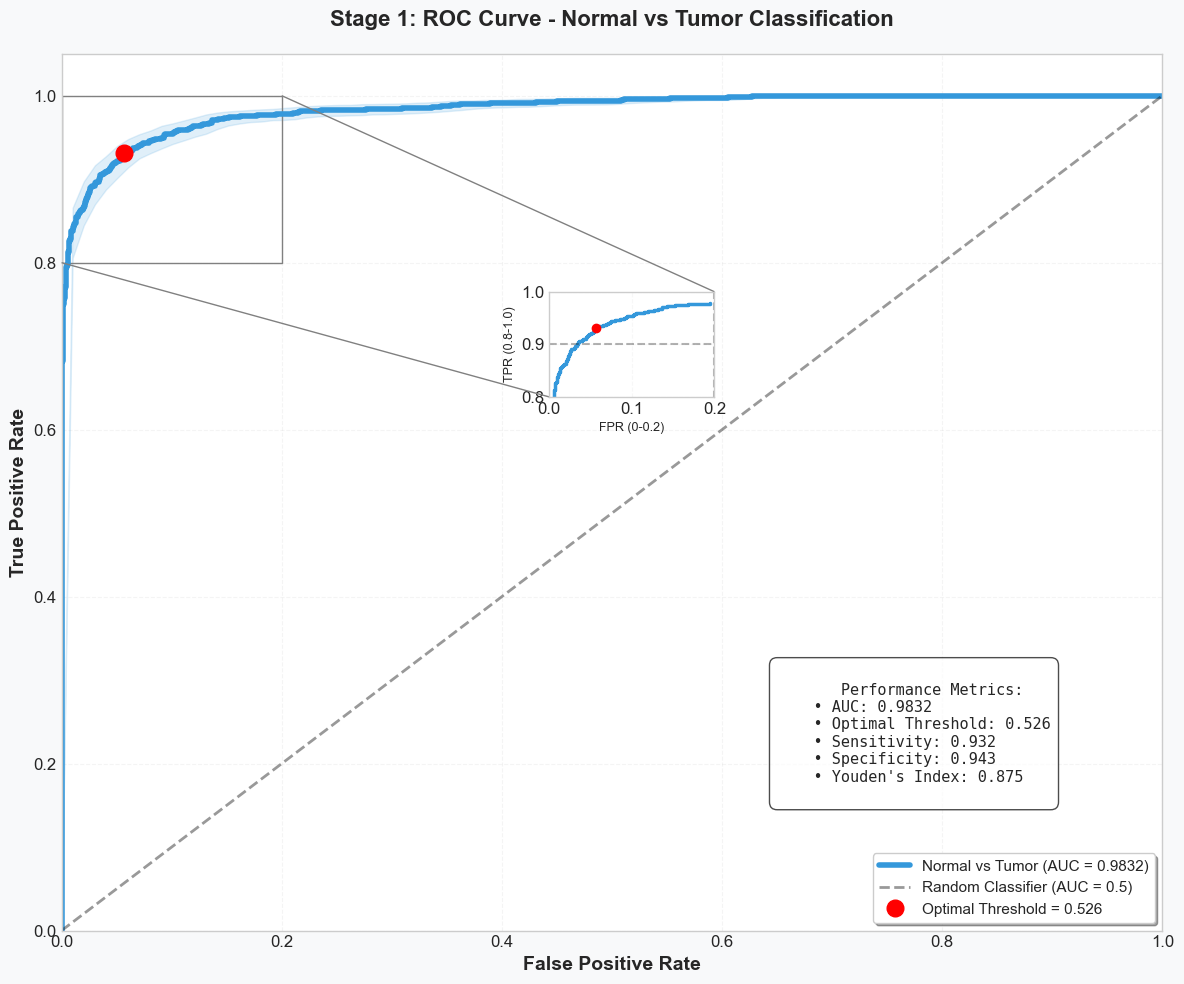

  Enhanced Stage 1 ROC curve saved


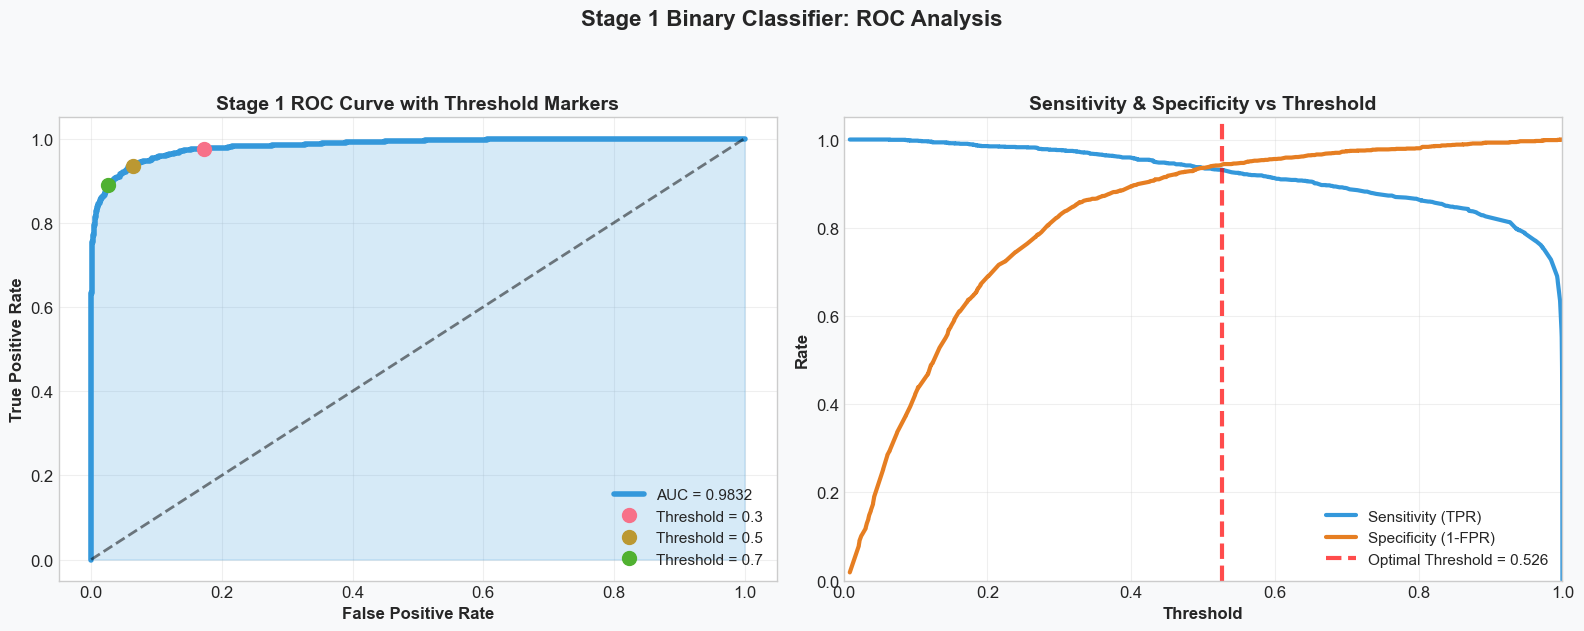

  Stage 1 ROC analysis saved

 STAGE 2: Preparing Multiclass Classifier Data


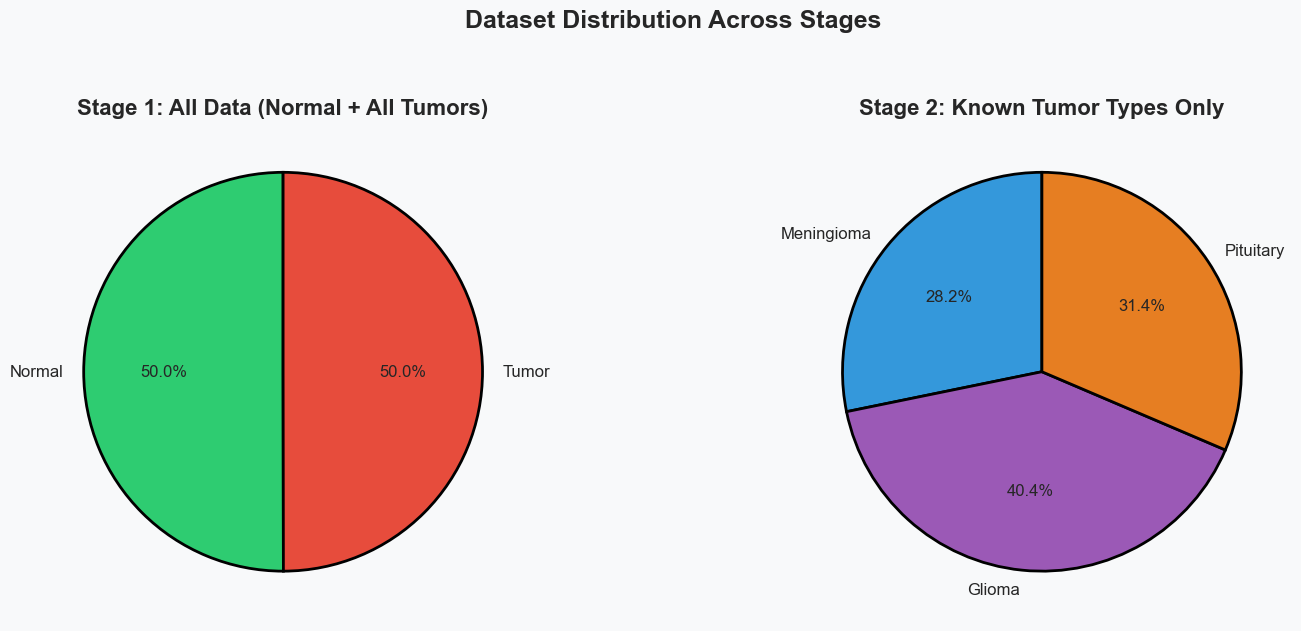

  Data distribution chart saved

 STAGE 2: Training Multiclass Classifier (Tumor Types)
Training samples: 4119
Validation samples: 835
Epoch 1/3
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.5693 - loss: 1.1037 - val_accuracy: 0.2946 - val_loss: 1.1660 - learning_rate: 0.0010
Epoch 2/3
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7257 - loss: 0.6404 - val_accuracy: 0.4180 - val_loss: 1.9198 - learning_rate: 0.0010
Epoch 3/3
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.7992 - loss: 0.4949 - val_accuracy: 0.5234 - val_loss: 1.8524 - learning_rate: 0.0010


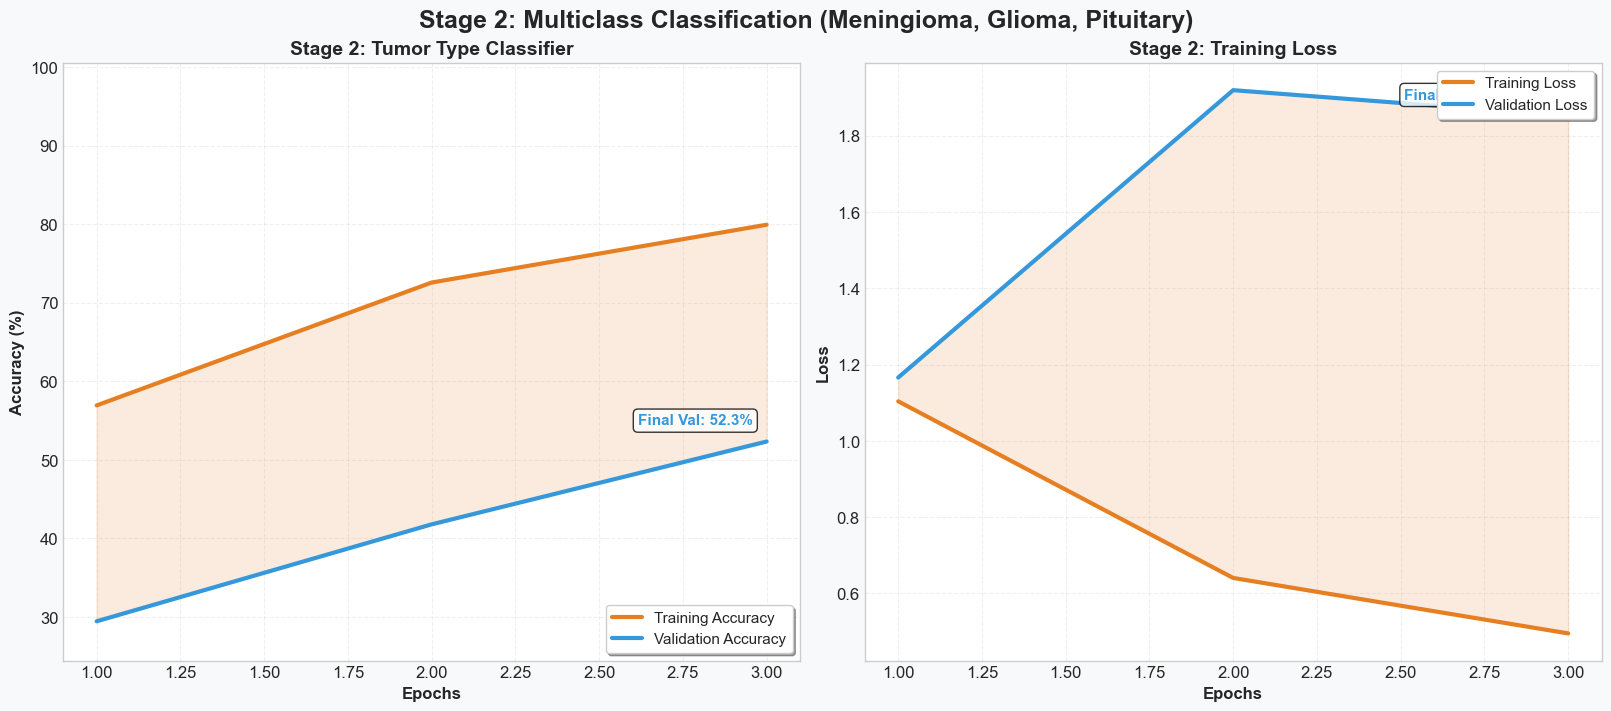

  Stage 2 training curves saved

   Evaluating Stage 2 Classifier


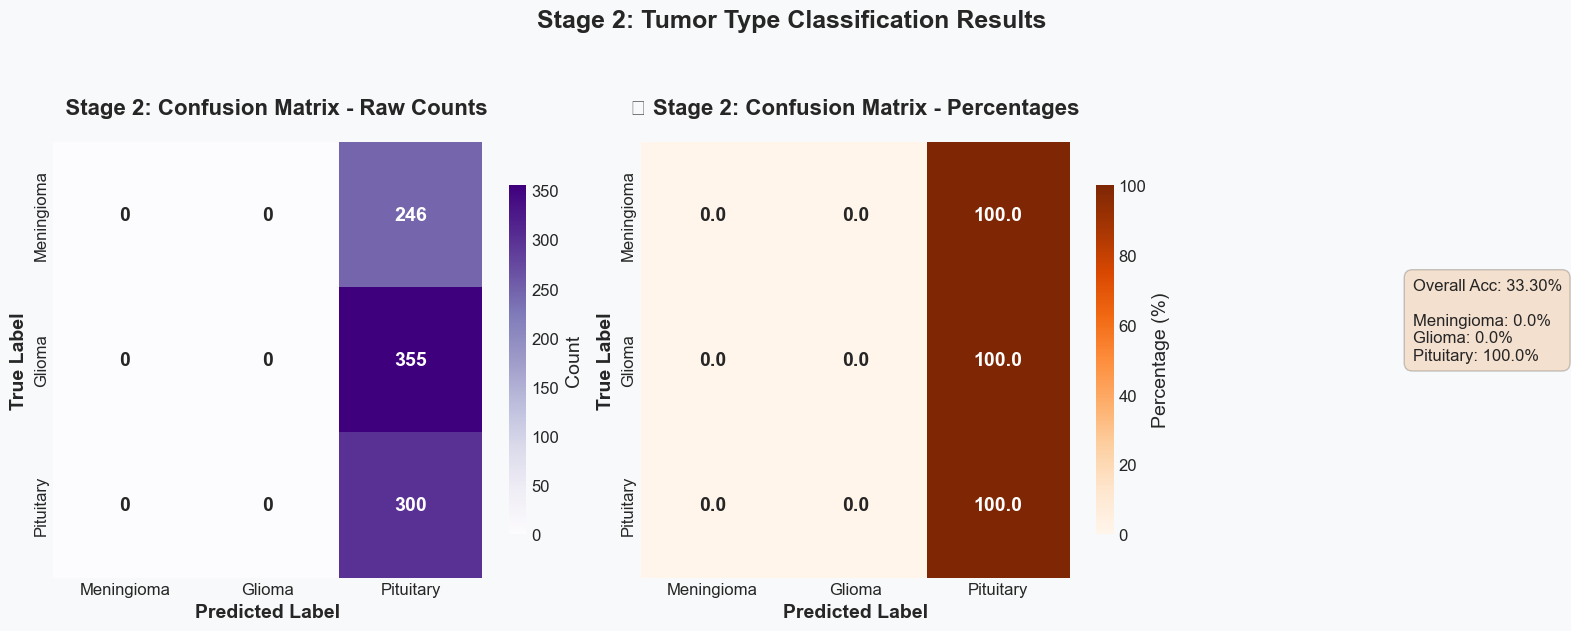

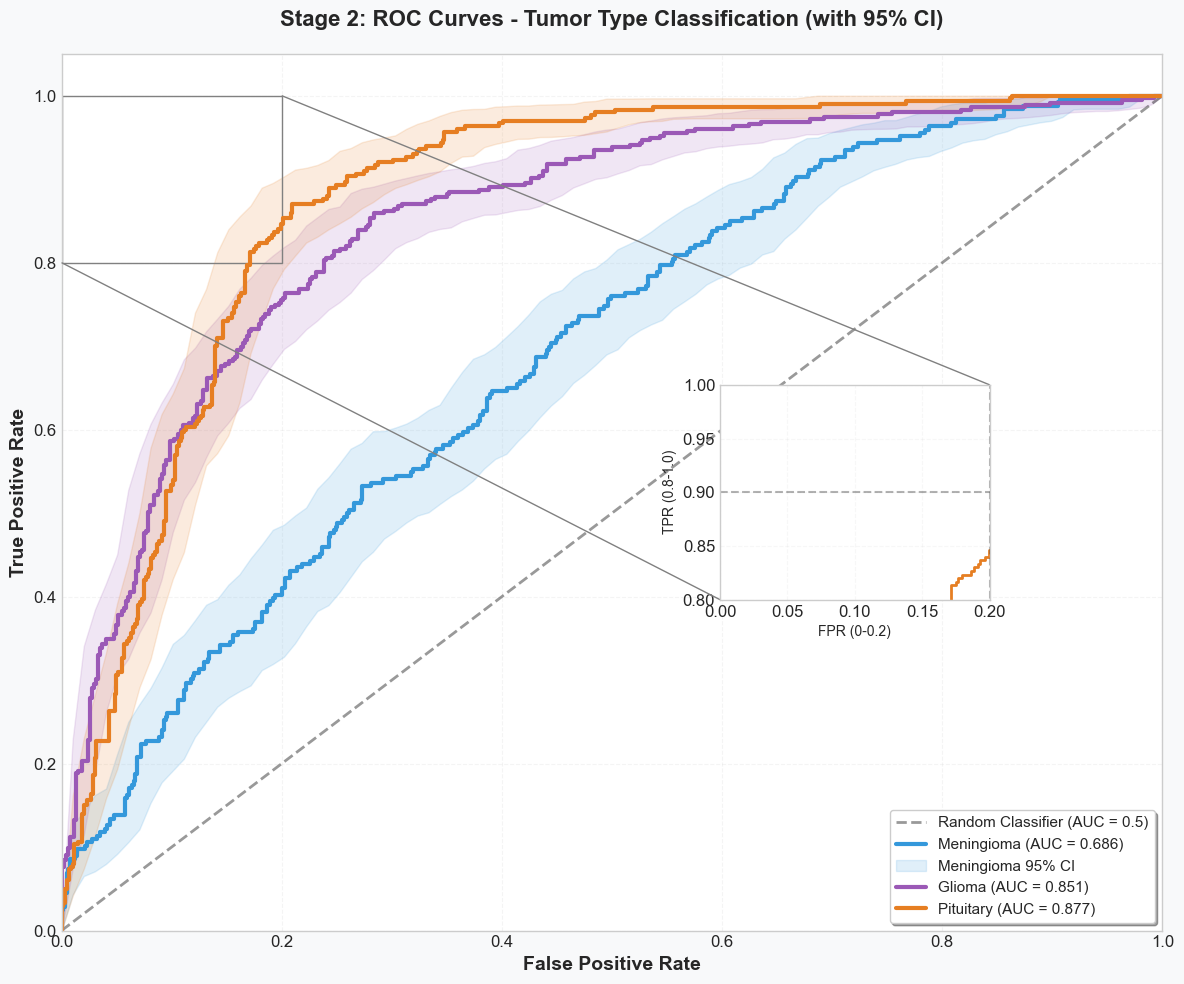

  Stage 2 ROC curves saved with 95% confidence intervals


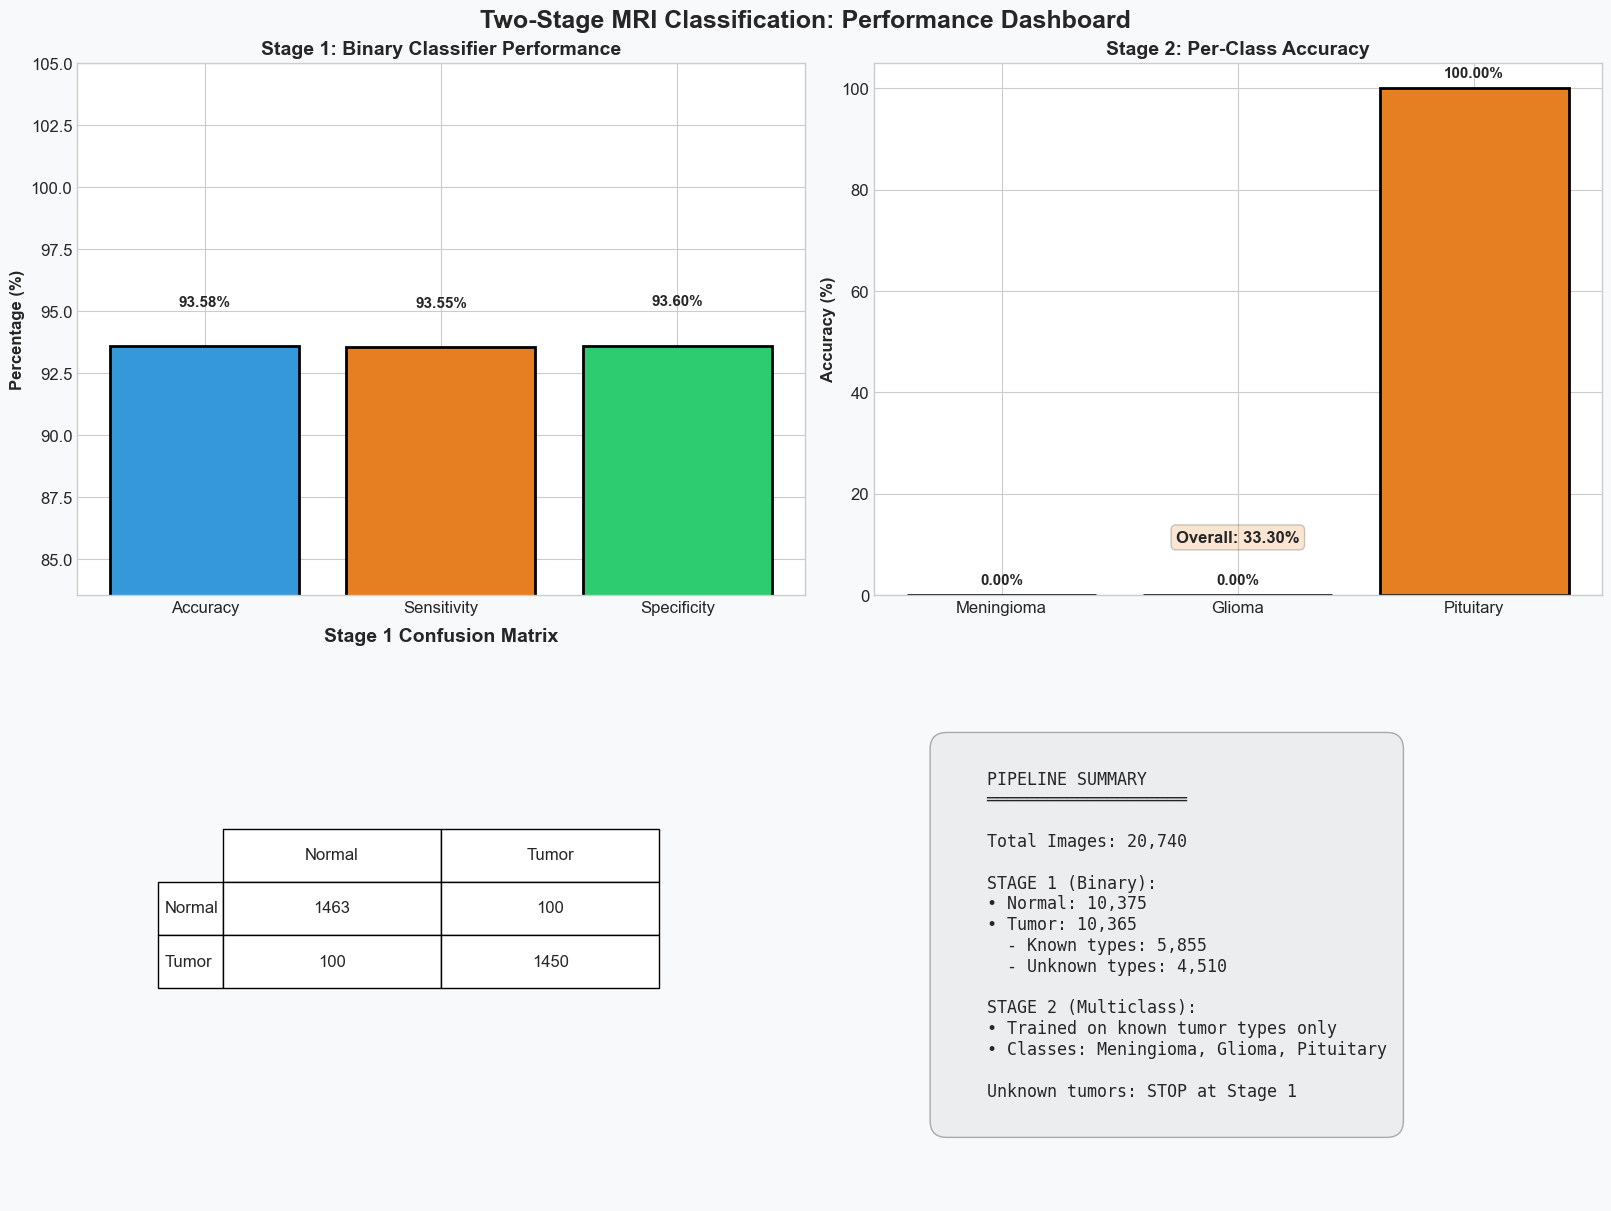

  Performance dashboard saved

 TWO-STAGE PIPELINE COMPLETED

   STAGE 1 RESULTS (Normal vs Tumor):
   Accuracy:    93.58%
   Sensitivity: 93.55%
   Specificity: 93.60%

 STAGE 2 RESULTS (Tumor Types):
   Overall Accuracy: 33.30%
   Meningioma: 0.00%
   Glioma: 0.00%
   Pituitary: 100.00%

 DATA SUMMARY:
   Total Normal: 10375
   Total Tumor:  10365
   Known Types:  5855
   Unknown Types: 4510 (handled by Stage 1 only)

 All figures saved to: ./presentation_figures_two_stage/


In [14]:
# ============================================================================
# CONFIGURATION Of STYLE AND PATHS
# ============================================================================

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['lines.linewidth'] = 3

# Custom cute color palette
COLORS = {
    'mri_primary': '#FF6B6B',      # Coral
    'mri_secondary': '#4ECDC4',     # Turquoise
    'normal': '#2ECC71',            # Green
    'meningioma': '#3498DB',         # Blue
    'glioma': '#9B59B6',             # Purple
    'pituitary': '#E67E22',          # Orange
    'tumor': '#E74C3C',              # Red
    'background': '#F8F9FA',         # Light gray
    'stage1': '#3498DB',              # Blue for stage 1
    'stage2': '#E67E22'               # Orange for stage 2
}

CONFIG = {
    'BASE_PATH': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/MRI',
    'MODEL_SAVE_PATH': './saved_models_mri_two_stage',
    'RESULTS_PATH': './results_mri_two_stage',
    'FIGURE_PATH': './presentation_figures_two_stage',
    'INPUT_SHAPE': (128, 128, 4),
    'NUM_CLASSES_STAGE1': 2,  # Binary: Normal vs Tumor
    'NUM_CLASSES_STAGE2': 3,  # Multiclass: Meningioma, Glioma, Pituitary
    'BATCH_SIZE': 32,
    'EPOCHS': 3,
    'LEARNING_RATE': 0.001,
}

STAGE1_CLASS_NAMES = ['Normal', 'Tumor']
STAGE2_CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']
STAGE2_COLORS = [COLORS['meningioma'], COLORS['glioma'], COLORS['pituitary']]

# Create directories
for path in [CONFIG['MODEL_SAVE_PATH'], CONFIG['RESULTS_PATH'], CONFIG['FIGURE_PATH']]:
    os.makedirs(path, exist_ok=True)
# Add this function after your CONFIG definition, before visualization functions
def bootstrap_roc_curve(y_true, y_score, n_bootstraps=1000, random_state=42):
    """
    Compute ROC curve with confidence intervals via bootstrapping.
    Returns aligned original and bootstrapped data.
    """
    from sklearn.utils import resample
    
    # Original ROC curve (keep EVERYTHING)
    fpr_orig, tpr_orig, thresholds_orig = roc_curve(y_true, y_score)
    
    # Common FPR grid for interpolation (for confidence bands only)
    fpr_grid = np.linspace(0, 1, 100)
    tprs = []
    
    for i in range(n_bootstraps):
        indices = resample(range(len(y_true)), replace=True, 
                          random_state=random_state + i)
        
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        fpr, tpr, _ = roc_curve(y_true[indices], y_score[indices])
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)
    
    if len(tprs) > 0:
        tprs = np.array(tprs)
        tpr_lower = np.percentile(tprs, 2.5, axis=0)
        tpr_upper = np.percentile(tprs, 97.5, axis=0)
    else:
        tpr_lower = np.maximum(0, tpr_orig - 0.02)
        tpr_upper = np.minimum(1, tpr_orig + 0.02)
        tpr_lower = np.interp(fpr_grid, fpr_orig, tpr_lower)
        tpr_upper = np.interp(fpr_grid, fpr_orig, tpr_upper)
    
    # Return EVERYTHING needed
    return {
        'fpr_orig': fpr_orig,
        'tpr_orig': tpr_orig,
        'thresholds_orig': thresholds_orig,
        'fpr_grid': fpr_grid,
        'tpr_lower': tpr_lower,
        'tpr_upper': tpr_upper,
        'roc_auc': auc(fpr_orig, tpr_orig)
    }
# ============================================================================
# FILENAME PARSER
# ============================================================================

def get_tumor_type_from_filename(filename):
    """Extract tumor type ONLY if present in filename"""
    try:
        parts = filename.replace('.npy', '').split('_')
        
        # Look for pattern ..._X_processed.npy where X is 1,2,3
        if len(parts) >= 2 and parts[-1] == 'processed':
            potential_code = parts[-2]
            if potential_code in ['1', '2', '3']:
                return int(potential_code)
        return None
    except Exception as e:
        return None

# ============================================================================
# STAGE 1: BINARY DATA GENERATOR
# ============================================================================

class Stage1BinaryGenerator(tf.keras.utils.Sequence):
    """Binary classifier generator - uses ALL data"""
    
    def __init__(self, directory, batch_size=32, shuffle=True, input_shape=(128,128,4)):
        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.input_shape = input_shape
        self.file_list = []
        self.labels = []  # 0 = Normal, 1 = Tumor
        self._scan_directory()
        self.on_epoch_end()

    def _scan_directory(self):
        # Normal files
        normal_path = os.path.join(self.directory, 'normal')
        if os.path.exists(normal_path):
            for f in os.listdir(normal_path):
                if f.endswith('.npy'):
                    self.file_list.append(os.path.join(normal_path, f))
                    self.labels.append(0)

        # Tumor files (ALL of them)
        tumor_path = os.path.join(self.directory, 'tumor')
        if os.path.exists(tumor_path):
            for f in os.listdir(tumor_path):
                if f.endswith('.npy'):
                    self.file_list.append(os.path.join(tumor_path, f))
                    self.labels.append(1)

    def __len__(self):
        return int(np.ceil(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.file_list))
        
        # 1. Grab the shuffled indexes for this specific batch
        batch_indexes = self.indexes[start:end]
        
        # 2. Use those indexes to get the randomized files and labels
        batch_files = [self.file_list[i] for i in batch_indexes]
        batch_labels = [self.labels[i] for i in batch_indexes]
        
        X = np.zeros((len(batch_files), *self.input_shape), dtype=np.float32)
        
        for i, f_path in enumerate(batch_files):
            try:
                img = np.load(f_path).astype(np.float32)
                if img.shape[:2] != self.input_shape[:2]:
                    img = tf.image.resize(img, (self.input_shape[:2])).numpy()
                
                X[i] = img
            except Exception as e:
                X[i] = np.zeros(self.input_shape)
        
        return X, to_categorical(batch_labels, num_classes=2)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indexes)

# ============================================================================
# STAGE 2: MULTICLASS DATA GENERATOR
# ============================================================================

class Stage2MulticlassGenerator(tf.keras.utils.Sequence):
    """Multiclass classifier generator - uses ONLY tumor files with known types"""
    
    def __init__(self, directory, batch_size=32, shuffle=True, input_shape=(128,128,4)):
        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.input_shape = input_shape
        self.file_list = []
        self.labels = []  # 1 = Meningioma, 2 = Glioma, 3 = Pituitary
        self._scan_directory()
        self.on_epoch_end()

    def _scan_directory(self):
        tumor_path = os.path.join(self.directory, 'tumor')
        if not os.path.exists(tumor_path):
            return

        for f in os.listdir(tumor_path):
            if not f.endswith('.npy'):
                continue
                
            tumor_type = get_tumor_type_from_filename(f)
            if tumor_type is not None:
                self.file_list.append(os.path.join(tumor_path, f))
                self.labels.append(tumor_type)

    def __len__(self):
        return int(np.ceil(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.file_list))
        
        # Grab the shuffled indexes
        batch_indexes = self.indexes[start:end]
        
        # Apply the shuffled indexes and shift labels to 0, 1, 2
        batch_files = [self.file_list[i] for i in batch_indexes]
        batch_labels = [self.labels[i] - 1 for i in batch_indexes]
        
        X = np.zeros((len(batch_files), *self.input_shape), dtype=np.float32)
        
        for i, f_path in enumerate(batch_files):
            try:
                img = np.load(f_path).astype(np.float32)
                if img.shape[:2] != self.input_shape[:2]:
                    img = tf.image.resize(img, (self.input_shape[:2])).numpy()
                
                # img = img / 255.0 # Uncomment if normalization is needed
                
                X[i] = img
            except Exception as e:
                X[i] = np.zeros(self.input_shape)
        
        return X, to_categorical(batch_labels, num_classes=3)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indexes)

# ============================================================================
# CNN MODEL
# ============================================================================

def build_cnn_model(num_classes, model_name="CNN_Model"):
    """Build CNN model with specified number of output classes"""
    
    inputs = layers.Input(shape=CONFIG['INPUT_SHAPE'], name="input_layer")

    # Block 1
    x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(16, (3, 3), padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 5
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1024, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', name='fc3')(x)
    
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def create_stage1_training_curves(history):
    """ Training history plots for Stage 1 (Binary Classifier)"""
    
    acc = np.array(history.history['accuracy']) * 100
    val_acc = np.array(history.history['val_accuracy']) * 100
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(acc) + 1)
    
    # Use constrained_layout to prevent title overlap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])
    
    # --- Accuracy Plot ---
    ax1.plot(epochs, acc, color=COLORS['stage1'], label='Training Accuracy', linewidth=3)
    ax1.plot(epochs, val_acc, color=COLORS['stage2'], label='Validation Accuracy', linewidth=3)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.15, color=COLORS['stage1'])
    
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Stage 1: Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Dynamic Y-axis: show data clearly but leave room at the top
    ax1.set_ylim([min(acc.min(), val_acc.min()) - 1, 100.5])
    
    # Robust Annotation: Place label at the last epoch
    final_val_acc = val_acc[-1]
    ax1.annotate(f'Final Val: {final_val_acc:.1f}%', 
                 xy=(epochs[-1], final_val_acc),
                 xytext=(-10, 10), textcoords='offset points',
                 ha='right', va='bottom',
                 fontsize=11, fontweight='bold', color=COLORS['stage2'],
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    # --- Loss Plot ---
    ax2.plot(epochs, loss, color=COLORS['stage1'], label='Training Loss', linewidth=3)
    ax2.plot(epochs, val_loss, color=COLORS['stage2'], label='Validation Loss', linewidth=3)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.15, color=COLORS['stage1'])
    
    ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Stage 1: Training Loss', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', frameon=True, shadow=True)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Robust Annotation for Loss
    final_val_loss = val_loss[-1]
    ax2.annotate(f'Final Val Loss: {final_val_loss:.3f}', 
                 xy=(epochs[-1], final_val_loss),
                 xytext=(-10, 10), textcoords='offset points',
                 ha='right', va='bottom',
                 fontsize=11, fontweight='bold', color=COLORS['stage2'],
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

    plt.suptitle('Stage 1: Binary Classification (Normal vs Tumor)', fontsize=18, fontweight='bold')
    
    # Save with high quality
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_training_curves.png'), 
                dpi=300, facecolor=COLORS['background'])
    plt.show()

def create_stage1_roc_curve(y_true, y_pred_proba):
    """
    Generate beautiful ROC curve for Stage 1 Binary Classifier
    Now properly aligned with all data
    """
    
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor(COLORS['background'])
    
    # Get ALL data from bootstrap function
    roc_data = bootstrap_roc_curve(y_true, y_pred_proba[:, 1], n_bootstraps=500)
    
    # Extract data
    fpr = roc_data['fpr_orig']
    tpr = roc_data['tpr_orig']
    thresholds = roc_data['thresholds_orig']
    fpr_grid = roc_data['fpr_grid']
    tpr_lower = roc_data['tpr_lower']
    tpr_upper = roc_data['tpr_upper']
    roc_auc = roc_data['roc_auc']
    
    # Optimal threshold using Youden's J statistic (using ORIGINAL aligned data)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_tpr = tpr[optimal_idx]
    optimal_fpr = fpr[optimal_idx]
    
    # Plot ROC curve
    ax.plot(fpr, tpr, color=COLORS['stage1'], lw=4, 
            label=f'Normal vs Tumor (AUC = {roc_auc:.4f})')
    
    # Add confidence shading using bootstrap intervals (on grid)
    ax.fill_between(fpr_grid, tpr_lower, tpr_upper, 
                    alpha=0.15, color=COLORS['stage1'])
    
    # Plot diagonal line
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', 
            alpha=0.4, linewidth=2)
    
    # Mark optimal threshold
    ax.plot(optimal_fpr, optimal_tpr, 'o', color='red', markersize=12,
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
    
    # Metrics text
    metrics_text = f"""
       Performance Metrics:
    • AUC: {roc_auc:.4f}
    • Optimal Threshold: {optimal_threshold:.3f}
    • Sensitivity: {optimal_tpr:.3f}
    • Specificity: {1-optimal_fpr:.3f}
    • Youden's Index: {j_scores[optimal_idx]:.3f}
    """
    
    ax.text(0.65, 0.15, metrics_text, fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7),
            transform=ax.transAxes, fontfamily='monospace')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    ax.set_title('Stage 1: ROC Curve - Normal vs Tumor Classification', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=11)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Inset for high-sensitivity region
    axins = inset_axes(ax, width="30%", height="30%", loc='lower right',
                       bbox_to_anchor=(0.1, 0.6, 0.5, 0.4), 
                       bbox_transform=ax.transAxes)
    
    # Zoom into high TPR / low FPR region (using ORIGINAL points)
    mask = fpr <= 0.2
    axins.plot(fpr[mask], tpr[mask], color=COLORS['stage1'], lw=2.5)
    axins.plot([0, 0.2], [0.9, 0.9], 'k--', alpha=0.3, linewidth=1.5)
    axins.plot([0.2, 0.2], [0, 1], 'k--', alpha=0.3, linewidth=1.5)
    axins.set_xlim([0, 0.2])
    axins.set_ylim([0.8, 1.0])
    axins.grid(True, alpha=0.15, linestyle='--')
    axins.set_xlabel('FPR (0-0.2)', fontsize=9)
    axins.set_ylabel('TPR (0.8-1.0)', fontsize=9)
    
    # Mark optimal threshold in inset if within range
    if optimal_fpr <= 0.2:
        axins.plot(optimal_fpr, optimal_tpr, 'o', color='red', markersize=6)
    
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="gray", linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_roc_curve_enhanced.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_roc_curve_enhanced.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    print("  Enhanced Stage 1 ROC curve saved")
    
    return roc_auc, optimal_threshold
    
    # Plot 2: Sensitivity vs Specificity across thresholds
    specificity = 1 - fpr
    
    ax2.plot(thresholds[:-1], tpr[:-1], color=COLORS['stage1'], lw=3, 
            label='Sensitivity (TPR)')
    ax2.plot(thresholds[:-1], specificity[:-1], color=COLORS['stage2'], lw=3, 
            label='Specificity (1-FPR)')
    ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Rate', fontsize=12, fontweight='bold')
    ax2.set_title('Sensitivity & Specificity vs Threshold', fontsize=14, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.05])
    
    # Find optimal threshold (Youden's J)
    j_scores = tpr[:-1] + specificity[:-1] - 1
    optimal_idx = np.argmax(j_scores)
    optimal_thresh = thresholds[optimal_idx]
    
    ax2.axvline(x=optimal_thresh, color='red', linestyle='--', alpha=0.7,
                label=f'Optimal Threshold = {optimal_thresh:.3f}')
    ax2.legend()
    
    plt.suptitle('Stage 1 Binary Classifier: ROC Analysis', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_roc_analysis.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_roc_analysis.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    print("  Stage 1 ROC analysis saved")

def create_stage2_training_curves(history):
    """Generate training history plots for Stage 2 (Multiclass Classifier)"""
    
    acc = np.array(history.history['accuracy']) * 100
    val_acc = np.array(history.history['val_accuracy']) * 100
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(acc) + 1)
    
    # Use constrained_layout to manage the spacing naturally
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])
    
    # --- Accuracy Plot ---
    ax1.plot(epochs, acc, color=COLORS['stage2'], label='Training Accuracy', linewidth=3)
    ax1.plot(epochs, val_acc, color=COLORS['meningioma'], label='Validation Accuracy', linewidth=3)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.15, color=COLORS['stage2'])
    
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Stage 2: Tumor Type Classifier', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Dynamic Y-axis: Uses the lowest accuracy value to set the bottom limit
    min_acc = min(acc.min(), val_acc.min())
    ax1.set_ylim([min_acc - 5, 100.5]) 
    
    # Robust Annotation: Anchored to the last epoch
    final_val_acc = val_acc[-1]
    ax1.annotate(f'Final Val: {final_val_acc:.1f}%', 
                 xy=(epochs[-1], final_val_acc),
                 xytext=(-10, 10), textcoords='offset points',
                 ha='right', va='bottom',
                 fontsize=11, fontweight='bold', color=COLORS['meningioma'],
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    # --- Loss Plot ---
    ax2.plot(epochs, loss, color=COLORS['stage2'], label='Training Loss', linewidth=3)
    ax2.plot(epochs, val_loss, color=COLORS['meningioma'], label='Validation Loss', linewidth=3)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.15, color=COLORS['stage2'])
    
    ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Stage 2: Training Loss', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', frameon=True, shadow=True)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Robust Annotation for Loss
    final_val_loss = val_loss[-1]
    ax2.annotate(f'Final Val Loss: {final_val_loss:.3f}', 
                 xy=(epochs[-1], final_val_loss),
                 xytext=(-10, 10), textcoords='offset points',
                 ha='right', va='bottom',
                 fontsize=11, fontweight='bold', color=COLORS['meningioma'],
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

    plt.suptitle('Stage 2: Multiclass Classification (Meningioma, Glioma, Pituitary)', 
                 fontsize=18, fontweight='bold')
    
    # Removed bbox_inches='tight' since constrained_layout handles it better
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage2_training_curves.png'), 
                dpi=300, facecolor=COLORS['background'])
    plt.show()
    
    print("  Stage 2 training curves saved")

def create_stage1_confusion_matrix(y_true, y_pred):
    """Generate beautiful confusion matrix for Stage 1"""
    
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS['background'])
    
    # Plot 1: Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=STAGE1_CLASS_NAMES, yticklabels=STAGE1_CLASS_NAMES,
                ax=axes[0], cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=14, fontweight='bold')
    axes[0].set_title(' Stage 1: Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold', pad=20)
    
    # Plot 2: Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', 
                xticklabels=STAGE1_CLASS_NAMES, yticklabels=STAGE1_CLASS_NAMES,
                ax=axes[1], cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[1].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=14, fontweight='bold')
    axes[1].set_title(' Stage 1: Confusion Matrix - Percentages', fontsize=16, fontweight='bold', pad=20)
    
    # Calculate metrics
    accuracy = np.trace(cm) / np.sum(cm)
    sensitivity = cm[1,1] / (cm[1,1] + cm[1,0])  # True Positive Rate
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])  # True Negative Rate
    
    # Add metrics text
    metrics_text = f'Accuracy: {accuracy*100:.2f}%\nSensitivity: {sensitivity*100:.2f}%\nSpecificity: {specificity*100:.2f}%'
    axes[1].text(1.8, 0.5, metrics_text, fontsize=14,
                bbox=dict(boxstyle="round,pad=0.5", facecolor=COLORS['stage1'], alpha=0.2),
                transform=axes[1].transAxes)
    
    plt.suptitle('Stage 1: Normal vs Tumor Classification Results', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_confusion_matrix.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage1_confusion_matrix.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    return accuracy, sensitivity, specificity

def create_stage2_confusion_matrix(y_true, y_pred):
    """Generate beautiful confusion matrix for Stage 2"""
    
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS['background'])
    
    # Plot 1: Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=STAGE2_CLASS_NAMES, yticklabels=STAGE2_CLASS_NAMES,
                ax=axes[0], cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=14, fontweight='bold')
    axes[0].set_title('   Stage 2: Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold', pad=20)
    
    # Plot 2: Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Oranges', 
                xticklabels=STAGE2_CLASS_NAMES, yticklabels=STAGE2_CLASS_NAMES,
                ax=axes[1], cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=14, fontweight='bold')
    axes[1].set_title('📈 Stage 2: Confusion Matrix - Percentages', fontsize=16, fontweight='bold', pad=20)
    
    # Calculate per-class accuracy
    accuracy = np.trace(cm) / np.sum(cm)
    per_class_acc = [cm[i,i] / np.sum(cm[i,:]) * 100 for i in range(3)]
    
    # Add per-class accuracy text
    textstr = '\n'.join([f'{STAGE2_CLASS_NAMES[i]}: {per_class_acc[i]:.1f}%' for i in range(3)])
    axes[1].text(1.8, 0.5, f'Overall Acc: {accuracy*100:.2f}%\n\n{textstr}', 
                fontsize=12, bbox=dict(boxstyle="round,pad=0.5", facecolor=COLORS['stage2'], alpha=0.2),
                transform=axes[1].transAxes)
    
    plt.suptitle('Stage 2: Tumor Type Classification Results', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage2_confusion_matrix.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage2_confusion_matrix.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    return accuracy

def create_stage2_roc_curves(y_true, y_pred_proba):
    """Generate beautiful ROC curves for Stage 2 with confidence intervals"""
    
    n_classes = 3
    
    # Binarize the output
    y_true_bin = np.zeros((len(y_true), n_classes))
    for i, label in enumerate(y_true):
        y_true_bin[i, label] = 1
    
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor(COLORS['background'])
    
    # Plot diagonal
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', 
            alpha=0.4, linewidth=2)
    
    # Calculate ROC for each class with confidence intervals
    for i, (name, color) in enumerate(zip(STAGE2_CLASS_NAMES, STAGE2_COLORS)):
        # Get data for this class (one-vs-rest)
        y_binary = y_true_bin[:, i]
        y_scores = y_pred_proba[:, i]
        
        # Bootstrap confidence intervals for ROC curve
        roc_data = bootstrap_roc_curve(y_binary, y_scores, n_bootstraps=300)
        
        # Extract data
        fpr = roc_data['fpr_orig']
        tpr = roc_data['tpr_orig']
        roc_auc = roc_data['roc_auc']
        fpr_grid = roc_data['fpr_grid']
        tpr_lower = roc_data['tpr_lower']
        tpr_upper = roc_data['tpr_upper']
        
        # Plot ROC curve (using ORIGINAL points)
        ax.plot(fpr, tpr, color=color, lw=3, 
                label=f'{name} (AUC = {roc_auc:.3f})')
        
        # Add confidence band (using grid for smooth shading)
        ax.fill_between(fpr_grid, tpr_lower, tpr_upper, 
                        alpha=0.15, color=color,
                        label=f'{name} 95% CI' if i == 0 else "")
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    ax.set_title('Stage 2: ROC Curves - Tumor Type Classification (with 95% CI)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=11)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Add inset zoom for high-sensitivity region (like Stage 1)
    axins = inset_axes(ax, width="35%", height="35%", loc='center right',
                       bbox_to_anchor=(0.15, 0.15, 0.7, 0.7), 
                       bbox_transform=ax.transAxes)
    
    for i, (name, color) in enumerate(zip(STAGE2_CLASS_NAMES, STAGE2_COLORS)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        mask = fpr <= 0.2
        axins.plot(fpr[mask], tpr[mask], color=color, lw=2)
    
    axins.plot([0, 0.2], [0.9, 0.9], 'k--', alpha=0.3, linewidth=1.5)
    axins.plot([0.2, 0.2], [0, 1], 'k--', alpha=0.3, linewidth=1.5)
    axins.set_xlim([0, 0.2])
    axins.set_ylim([0.8, 1.0])
    axins.grid(True, alpha=0.15, linestyle='--')
    axins.set_xlabel('FPR (0-0.2)', fontsize=10)
    axins.set_ylabel('TPR (0.8-1.0)', fontsize=10)
    
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="gray", linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage2_roc_curves.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'stage2_roc_curves.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    print("  Stage 2 ROC curves saved with 95% confidence intervals")

def create_data_distribution_chart(train_gen1, val_gen1, test_gen1, train_gen2):
    """Create a beautiful data distribution chart"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS['background'])
    
    # Stage 1 distribution
    stage1_counts = [
        sum(1 for l in train_gen1.labels if l == 0) + sum(1 for l in val_gen1.labels if l == 0) + sum(1 for l in test_gen1.labels if l == 0),
        sum(1 for l in train_gen1.labels if l == 1) + sum(1 for l in val_gen1.labels if l == 1) + sum(1 for l in test_gen1.labels if l == 1)
    ]
    
    wedges, texts, autotexts = ax1.pie(stage1_counts, 
                                       labels=STAGE1_CLASS_NAMES,
                                       autopct='%1.1f%%',
                                       colors=[COLORS['normal'], COLORS['tumor']],
                                       startangle=90,
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    ax1.set_title('Stage 1: All Data (Normal + All Tumors)', fontsize=16, fontweight='bold')
    
    # Stage 2 distribution
    if train_gen2.file_list:
        stage2_labels = train_gen2.labels + (val_gen2.labels if 'val_gen2' in dir() else []) + (test_gen2.labels if 'test_gen2' in dir() else [])
        stage2_counts = [sum(1 for l in stage2_labels if l == i+1) for i in range(3)]
        
        wedges, texts, autotexts = ax2.pie(stage2_counts,
                                           labels=STAGE2_CLASS_NAMES,
                                           autopct='%1.1f%%',
                                           colors=STAGE2_COLORS,
                                           startangle=90,
                                           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
        ax2.set_title('Stage 2: Known Tumor Types Only', fontsize=16, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No known tumor types found', ha='center', fontsize=14)
    
    plt.suptitle('   Dataset Distribution Across Stages', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'data_distribution.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS['background'])
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'data_distribution.pdf'), 
                bbox_inches='tight', facecolor=COLORS['background'])
    plt.show()
    
    print("  Data distribution chart saved")

def create_performance_summary_dashboard(stage1_metrics, stage2_metrics, stage2_exists=True):
    """Create a beautiful performance summary dashboard"""
    
    # Use constrained_layout instead of tight_layout for better spacing
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])
    
    # --- Stage 1 metrics bar chart ---
    ax1 = axes[0, 0]
    metrics = ['Accuracy', 'Sensitivity', 'Specificity']
    values = [stage1_metrics['accuracy']*100, stage1_metrics['sensitivity']*100, stage1_metrics['specificity']*100]
    
    bars = ax1.bar(metrics, values, color=[COLORS['stage1'], COLORS['stage2'], COLORS['normal']],
                   edgecolor='black', linewidth=2)
                   
    # Dynamic Y-axis: Find the lowest value and give it some padding, but don't go below 0
    min_val = min(values)
    ax1.set_ylim([max(0, min_val - 10), 105])
    
    ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Stage 1: Binary Classifier Performance', fontsize=14, fontweight='bold')
    
    for bar, v in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # --- Stage 2 metrics if available ---
    ax2 = axes[0, 1]
    if stage2_exists:
        class_names = STAGE2_CLASS_NAMES
        class_acc = [stage2_metrics['class_acc'][i]*100 for i in range(3)]
        
        bars = ax2.bar(class_names, class_acc, color=STAGE2_COLORS,
                       edgecolor='black', linewidth=2)
                       
        # Dynamic Y-axis for Stage 2
        min_acc = min(class_acc)
        ax2.set_ylim([max(0, min_acc - 10), 105])
        
        ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        ax2.set_title('Stage 2: Per-Class Accuracy', fontsize=14, fontweight='bold')
        
        for bar, v in zip(bars, class_acc):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        ax2.text(0.5, 0.1, f'Overall: {stage2_metrics["accuracy"]*100:.2f}%', 
                ha='center', transform=ax2.transAxes, fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=COLORS['stage2'], alpha=0.2))
    else:
        ax2.text(0.5, 0.5, 'Stage 2 Not Trained\n(No known tumor types)', 
                ha='center', fontsize=14, style='italic')
    
    # --- Confusion matrix summary ---
    ax3 = axes[1, 0]
    ax3.axis('off')
    
    cell_text = [[str(stage1_metrics['cm'][i,j]) for j in range(2)] for i in range(2)]
    table = ax3.table(cellText=cell_text, rowLabels=STAGE1_CLASS_NAMES,
                      colLabels=STAGE1_CLASS_NAMES,
                      cellLoc='center', loc='center',
                      bbox=[0.2, 0.4, 0.6, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    ax3.set_title('Stage 1 Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
    
    # --- Pipeline summary ---
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    total_normal = stage1_metrics['normal_count']
    total_tumor = stage1_metrics['tumor_count']
    known_tumors = stage2_metrics.get('total_samples', 0) if stage2_exists else 0
    unknown_tumors = total_tumor - known_tumors
    
    summary_text = f"""
    PIPELINE SUMMARY
    ════════════════════
    
    Total Images: {total_normal + total_tumor:,}
    
    STAGE 1 (Binary):
    • Normal: {total_normal:,}
    • Tumor: {total_tumor:,}
      - Known types: {known_tumors:,}
      - Unknown types: {unknown_tumors:,}
    
    STAGE 2 (Multiclass):
    • Trained on known tumor types only
    • Classes: {', '.join(STAGE2_CLASS_NAMES)}
    
    Unknown tumors: STOP at Stage 1
    """
    
    ax4.text(0.1, 0.5, summary_text, fontsize=12, fontfamily='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle="round,pad=1", facecolor='lightgray', alpha=0.3))
    
    plt.suptitle('Two-Stage MRI Classification: Performance Dashboard', 
                 fontsize=18, fontweight='bold')
    
    # No need for bbox_inches='tight' anymore as constrained_layout handles the margins
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'performance_dashboard.png'), 
                dpi=300, facecolor=COLORS['background'])
    plt.show()
    
    print("  Performance dashboard saved")

# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def train_stage1(train_gen, val_gen):
    """Train binary classifier (Normal vs Tumor)"""
    
    print("\n" + "="*70)
    print(" STAGE 1: Training Binary Classifier (Normal vs Tumor)")
    print("="*70)
    print(f"Training samples: {len(train_gen.file_list)}")
    print(f"Validation samples: {len(val_gen.file_list)}")
    
    model = build_cnn_model(2, "Stage1_Binary_Model")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        train_gen,
        epochs=CONFIG['EPOCHS'],
        validation_data=val_gen,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
        ]
    )
    
    # Save model
    model.save(os.path.join(CONFIG['MODEL_SAVE_PATH'], 'stage1_binary_model.keras'))
    
    # Create training curves
    create_stage1_training_curves(history)
    
    return model, history

def train_stage2(train_gen, val_gen):
    """Train multiclass classifier (Meningioma vs Glioma vs Pituitary)"""
    
    print("\n" + "="*70)
    print(" STAGE 2: Training Multiclass Classifier (Tumor Types)")
    print("="*70)
    print(f"Training samples: {len(train_gen.file_list)}")
    print(f"Validation samples: {len(val_gen.file_list)}")
    
    model = build_cnn_model(3, "Stage2_Multiclass_Model")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        train_gen,
        epochs=CONFIG['EPOCHS'],
        validation_data=val_gen,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
        ]
    )
    
    # Save model
    model.save(os.path.join(CONFIG['MODEL_SAVE_PATH'], 'stage2_multiclass_model.keras'))
    
    # Create training curves
    create_stage2_training_curves(history)
    
    return model, history

# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_two_stage_pipeline():
    """Run the complete two-stage classification pipeline"""
    
    print("\n" + "="*70)
    print(" TWO-STAGE MRI CLASSIFICATION PIPELINE")
    print("="*70)
    print("\n Stage 1: Binary Classifier (Normal vs Tumor) - uses ALL data")
    print(" Stage 2: Multiclass Classifier (Tumor Types) - uses ONLY known tumor types")
    
    # ==================== STAGE 1: Binary Classifier ====================
    print("\n" + "="*70)
    print(" STAGE 1: Preparing Binary Classifier Data")
    print("="*70)

    train_gen_stage1 = Stage1BinaryGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'train'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=True
    )
    
    val_gen_stage1 = Stage1BinaryGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'val'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=False
    )
    
    test_gen_stage1 = Stage1BinaryGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'test'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=False
    )
    # Train Stage 1
    stage1_model, stage1_history = train_stage1(train_gen_stage1, val_gen_stage1)

    # Evaluate Stage 1
    print("\n" + "="*70)
    print("   Evaluating Stage 1 Classifier")
    print("="*70)

    # Get predictions
    y_pred_stage1 = []
    y_true_stage1 = []
    y_pred_proba_stage1 = []  # For ROC curve

    for i in range(len(test_gen_stage1)):
        X_batch, y_batch = test_gen_stage1[i]
        pred_batch = stage1_model.predict(X_batch, verbose=0)
        y_pred_proba_stage1.extend(pred_batch)  # Store probabilities
        y_pred_stage1.extend(np.argmax(pred_batch, axis=1))
        y_true_stage1.extend(np.argmax(y_batch, axis=1))

    y_true_stage1 = np.array(y_true_stage1)
    y_pred_stage1 = np.array(y_pred_stage1)
    y_pred_proba_stage1 = np.array(y_pred_proba_stage1)

    # Create confusion matrix
    acc, sens, spec = create_stage1_confusion_matrix(y_true_stage1, y_pred_stage1)

    # Create ROC curve for Stage 1
    roc_auc, optimal_thresh = create_stage1_roc_curve(y_true_stage1, y_pred_proba_stage1)

    # Optional: Create the comparison view
    create_stage1_roc_comparison(y_true_stage1, y_pred_proba_stage1)

    stage1_metrics = {
        'accuracy': acc,
        'sensitivity': sens,
        'specificity': spec,
        'roc_auc': roc_auc,
        'optimal_threshold': optimal_thresh,
        'cm': confusion_matrix(y_true_stage1, y_pred_stage1),
        'normal_count': sum(1 for l in train_gen_stage1.labels if l == 0) + 
                        sum(1 for l in val_gen_stage1.labels if l == 0) + 
                        sum(1 for l in test_gen_stage1.labels if l == 0),
        'tumor_count': sum(1 for l in train_gen_stage1.labels if l == 1) + 
                    sum(1 for l in val_gen_stage1.labels if l == 1) + 
                    sum(1 for l in test_gen_stage1.labels if l == 1)
}
    # ==================== STAGE 2: Multiclass Classifier ====================
    print("\n" + "="*70)
    print(" STAGE 2: Preparing Multiclass Classifier Data")
    print("="*70)
    
    train_gen_stage2 = Stage2MulticlassGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'train'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=True
    )
    
    val_gen_stage2 = Stage2MulticlassGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'val'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=False
    )
    
    test_gen_stage2 = Stage2MulticlassGenerator(
        os.path.join(CONFIG['BASE_PATH'], 'test'),
        batch_size=CONFIG['BATCH_SIZE'],
        shuffle=False
    )
    
    # Create data distribution chart
    create_data_distribution_chart(train_gen_stage1, val_gen_stage1, test_gen_stage1, train_gen_stage2)
    
    
    # Train Stage 2 if data available
    stage2_exists = len(train_gen_stage2) > 0
    stage2_metrics = {}
    
    if stage2_exists:
        stage2_model, stage2_history = train_stage2(train_gen_stage2, val_gen_stage2)
        
        # Evaluate Stage 2
        print("\n" + "="*70)
        print("   Evaluating Stage 2 Classifier")
        print("="*70)
        
        y_pred_stage2 = []
        y_true_stage2 = []
        y_proba_stage2 = []
        
        for i in range(len(test_gen_stage2)):
            X_batch, y_batch = test_gen_stage2[i]
            pred_batch = stage2_model.predict(X_batch, verbose=0)
            y_pred_stage2.extend(np.argmax(pred_batch, axis=1))
            y_true_stage2.extend(np.argmax(y_batch, axis=1))
            y_proba_stage2.extend(pred_batch)
        
        y_true_stage2 = np.array(y_true_stage2)
        y_pred_stage2 = np.array(y_pred_stage2)
        y_proba_stage2 = np.array(y_proba_stage2)
        
        # Create visualizations
        stage2_acc = create_stage2_confusion_matrix(y_true_stage2, y_pred_stage2)
        create_stage2_roc_curves(y_true_stage2, y_proba_stage2)
        
        # Calculate per-class accuracy
        class_acc = []
        for i in range(3):
            mask = y_true_stage2 == i
            if np.sum(mask) > 0:
                class_acc.append(np.mean(y_pred_stage2[mask] == i))
            else:
                class_acc.append(0)
        
        stage2_metrics = {
            'accuracy': stage2_acc,
            'class_acc': class_acc,
            'total_samples': len(train_gen_stage2.file_list) + len(val_gen_stage2.file_list) + len(test_gen_stage2.file_list)
        }
    else:
        print("\n No known tumor types found for Stage 2 training.")
        print("   Stage 2 will be skipped.")
    
    # Create final dashboard
    create_performance_summary_dashboard(stage1_metrics, stage2_metrics, stage2_exists)
    
    # Final summary
    print("\n" + "="*70)
    print(" TWO-STAGE PIPELINE COMPLETED")
    print("="*70)
    print(f"\n   STAGE 1 RESULTS (Normal vs Tumor):")
    print(f"   Accuracy:    {stage1_metrics['accuracy']*100:.2f}%")
    print(f"   Sensitivity: {stage1_metrics['sensitivity']*100:.2f}%")
    print(f"   Specificity: {stage1_metrics['specificity']*100:.2f}%")
    
    if stage2_exists:
        print(f"\n STAGE 2 RESULTS (Tumor Types):")
        print(f"   Overall Accuracy: {stage2_metrics['accuracy']*100:.2f}%")
        for i, name in enumerate(STAGE2_CLASS_NAMES):
            print(f"   {name}: {stage2_metrics['class_acc'][i]*100:.2f}%")
    
    unknown_tumors = stage1_metrics['tumor_count'] - stage2_metrics.get('total_samples', 0)
    print(f"\n DATA SUMMARY:")
    print(f"   Total Normal: {stage1_metrics['normal_count']}")
    print(f"   Total Tumor:  {stage1_metrics['tumor_count']}")
    print(f"   Known Types:  {stage2_metrics.get('total_samples', 0)}")
    print(f"   Unknown Types: {unknown_tumors} (handled by Stage 1 only)")
    
    print(f"\n All figures saved to: {CONFIG['FIGURE_PATH']}/")
    
    return stage1_metrics, stage2_metrics

# ============================================================================
# EXECUTE
# ============================================================================

if __name__ == "__main__":
    stage1_metrics, stage2_metrics = run_two_stage_pipeline()